In [7]:
import json

sentences = []
labels = []
urls = []

with open('Sarcasm_Headlines_Dataset.json', 'r') as f:
    for line in f:
        if line.strip():
            data = json.loads(line)
            sentences.append(data['headline'])
            labels.append(data['is_sarcastic'])
            urls.append(data['article_link'])


In [13]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


vocab_size = 10000
embedding_dim = 16
max_length = 100
trunc_type='post'
padding_type='post'
oov_tok = "<OOV>"
training_size = 20000

# Train test split

In [14]:
training_sentences = sentences[0:training_size]
testing_sentences = sentences[training_size:]

training_labels = labels[0:training_size]
testing_labels = labels[training_size:]

# Tokenize

In [15]:
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(training_sentences)

word_index = tokenizer.word_index

training_sequences = tokenizer.texts_to_sequences(training_sentences)
training_padded = pad_sequences(training_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

testing_sequences = tokenizer.texts_to_sequences(testing_sentences)
testing_padded = pad_sequences(testing_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

# Apply

In [20]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, embedding_dim),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(24, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [21]:
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
num_epochs = 30
history = model.fit(training_padded, training_labels, epochs=num_epochs, validation_data=(testing_padded, testing_labels), verbose=2)

Epoch 1/30
625/625 - 4s - 7ms/step - accuracy: 0.5641 - loss: 0.6810 - val_accuracy: 0.5637 - val_loss: 0.6612
Epoch 2/30
625/625 - 3s - 5ms/step - accuracy: 0.7181 - loss: 0.5599 - val_accuracy: 0.8152 - val_loss: 0.4593
Epoch 3/30
625/625 - 3s - 5ms/step - accuracy: 0.8150 - loss: 0.4145 - val_accuracy: 0.8183 - val_loss: 0.4095
Epoch 4/30
625/625 - 4s - 6ms/step - accuracy: 0.8456 - loss: 0.3598 - val_accuracy: 0.7839 - val_loss: 0.4426
Epoch 5/30
625/625 - 3s - 5ms/step - accuracy: 0.8666 - loss: 0.3191 - val_accuracy: 0.8031 - val_loss: 0.4154
Epoch 6/30
625/625 - 3s - 5ms/step - accuracy: 0.8790 - loss: 0.2933 - val_accuracy: 0.8481 - val_loss: 0.3534
Epoch 7/30
625/625 - 4s - 6ms/step - accuracy: 0.8868 - loss: 0.2716 - val_accuracy: 0.8509 - val_loss: 0.3470
Epoch 8/30
625/625 - 4s - 7ms/step - accuracy: 0.8967 - loss: 0.2542 - val_accuracy: 0.8422 - val_loss: 0.3546
Epoch 9/30
625/625 - 3s - 4ms/step - accuracy: 0.9082 - loss: 0.2328 - val_accuracy: 0.8198 - val_loss: 0.4106
E

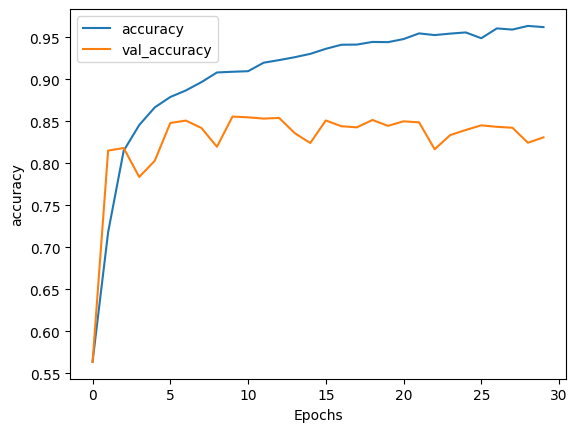

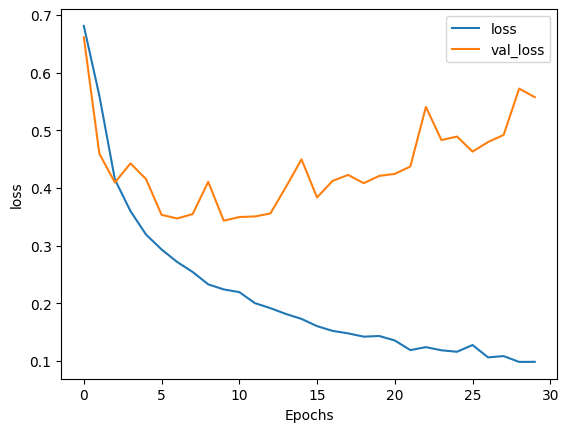

In [23]:
import matplotlib.pyplot as plt


def plot_graphs(history, string):
  plt.plot(history.history[string])
  plt.plot(history.history['val_'+string])
  plt.xlabel("Epochs")
  plt.ylabel(string)
  plt.legend([string, 'val_'+string])
  plt.show()

plot_graphs(history, "accuracy")
plot_graphs(history, "loss")